<a href="https://colab.research.google.com/github/keeg2025/DataScienceCapstone25/blob/main/StartingFinalProjectWork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
df = pd.read_csv('/content/sample_data/Airline_Delay_Cause.csv')
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,12,MQ,Envoy Air,EVV,"Evansville, IN: Evansville Regional",61.0,9.0,1.52,1.08,...,0.0,5.84,0.0,0.0,732.0,47.0,90.0,19.0,0.0,576.0
1,2024,12,MQ,Envoy Air,EWR,"Newark, NJ: Newark Liberty International",107.0,42.0,6.01,5.89,...,0.0,4.94,0.0,0.0,2531.0,335.0,491.0,1251.0,0.0,454.0
2,2024,12,MQ,Envoy Air,EYW,"Key West, FL: Key West International",169.0,31.0,3.37,0.71,...,0.0,15.48,5.0,3.0,1596.0,143.0,52.0,468.0,0.0,933.0
3,2024,12,MQ,Envoy Air,FAR,"Fargo, ND: Hector International",171.0,35.0,4.64,2.12,...,0.0,12.92,2.0,0.0,2428.0,245.0,184.0,575.0,0.0,1424.0
4,2024,12,MQ,Envoy Air,FSD,"Sioux Falls, SD: Joe Foss Field",69.0,14.0,2.00,2.47,...,0.0,4.83,1.0,0.0,720.0,86.0,154.0,191.0,0.0,289.0


In [29]:
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,140875.000000,140875.000000,140586.000000,140348.000000,140586.000000,140586.000000,140586.000000,140586.00000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000
mean,2021.397516,6.563421,298.141294,54.200138,18.117141,1.999597,14.849566,0.15736,18.984712,6.831036,0.704217,3726.449824,1338.031162,218.773925,715.527912,7.343078,1446.754535
std,1.765894,3.506382,870.094634,161.713315,49.141188,7.340959,51.215436,0.76626,64.781190,44.891064,3.261713,12515.613824,4473.922752,898.655113,2879.914973,42.863965,5294.934873
min,2018.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,3.000000,35.000000,5.000000,1.730000,0.000000,0.740000,0.00000,0.970000,0.000000,0.000000,254.000000,78.000000,0.000000,21.000000,0.000000,39.000000
50%,2021.000000,7.000000,82.000000,13.000000,4.975000,0.150000,2.910000,0.00000,3.690000,1.000000,0.000000,816.000000,289.000000,9.000000,108.000000,0.000000,242.000000
75%,2023.000000,10.000000,194.000000,36.000000,13.690000,1.550000,8.540000,0.00000,11.480000,3.000000,0.000000,2355.000000,932.000000,128.000000,351.000000,0.000000,876.000000
max,2024.000000,12.000000,21873.000000,5544.000000,1886.580000,325.410000,1685.740000,58.69000,2588.130000,4951.000000,192.000000,648300.000000,321792.000000,64550.000000,139958.000000,3760.000000,279153.000000


In [30]:
# prompt: can you get me the number of uniques airports in df

# Assuming 'airport' is the column containing airport information
num_unique_airports = df['airport'].nunique()
print(f"Number of unique airports: {num_unique_airports}")


Number of unique airports: 388


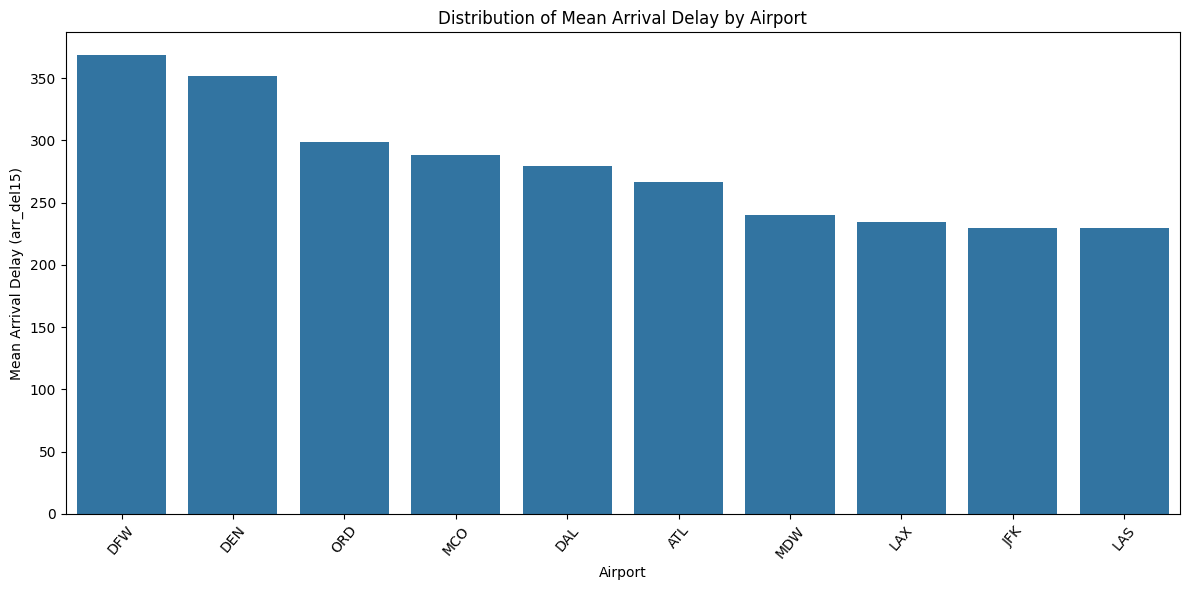

In [31]:
# prompt: make a graph to show the distribution of the arr_del15 by airport (delay #)

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'arr_del15' and 'airport' are the relevant columns
# Group the data by airport and calculate the mean of arr_del15
airport_delay_distribution = df.groupby('airport')['arr_del15'].mean()
    #airport_delay_distribution = airport_delay_distribution[(airport_delay_distribution >= 100)]
airport_delay_distribution = airport_delay_distribution.nlargest(10)


# Create a bar plot of the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=airport_delay_distribution.index, y=airport_delay_distribution.values)
plt.xlabel('Airport')
plt.ylabel('Mean Arrival Delay (arr_del15)')
plt.title('Distribution of Mean Arrival Delay by Airport')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()


In [32]:
# prompt: subset df by airport = "DEN"

# Subset the DataFrame where the 'airport' column is equal to 'DEN'
den_df = df[df['airport'] == 'DEN']

# Print the subsetted DataFrame
print(den_df.head())


      year  month carrier               carrier_name airport  \
308   2024     12      OO      SkyWest Airlines Inc.     DEN   
628   2024     12      UA   United Air Lines Network     DEN   
746   2024     12      WN         Southwest Airlines     DEN   
1053  2024     12      AA  American Airlines Network     DEN   
1169  2024     12      AS    Alaska Airlines Network     DEN   

                          airport_name  arr_flights  arr_del15  carrier_ct  \
308   Denver, CO: Denver International       5791.0      749.0      404.30   
628   Denver, CO: Denver International       8538.0     1050.0      420.34   
746   Denver, CO: Denver International       7668.0     1320.0      381.48   
1053  Denver, CO: Denver International        726.0      175.0       66.56   
1169  Denver, CO: Denver International        167.0       18.0        4.75   

      weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
308        67.72  ...         1.56            179.24           36.0   
628 

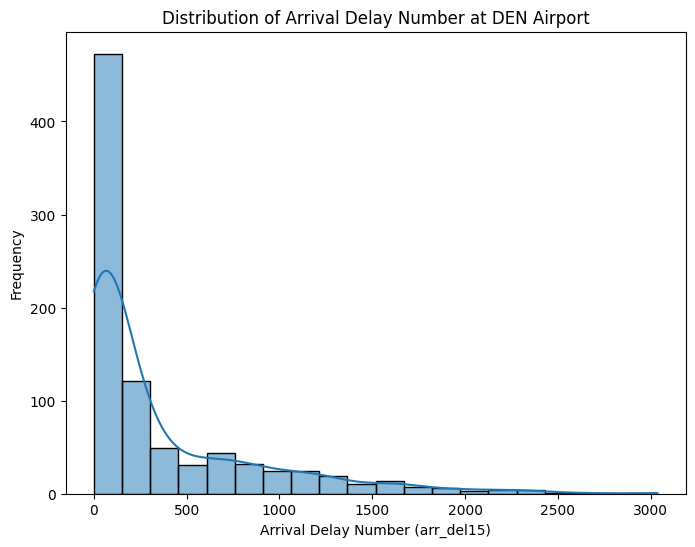

In [33]:
# prompt: can you make a barplot to show the distribution of arr_del15 in the den_df

import matplotlib.pyplot as plt
# Assuming 'arr_del15' is the column you want to analyze in den_df
plt.figure(figsize=(8, 6))
sns.histplot(den_df['arr_del15'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Arrival Delay Number (arr_del15)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Number at DEN Airport')
plt.show()


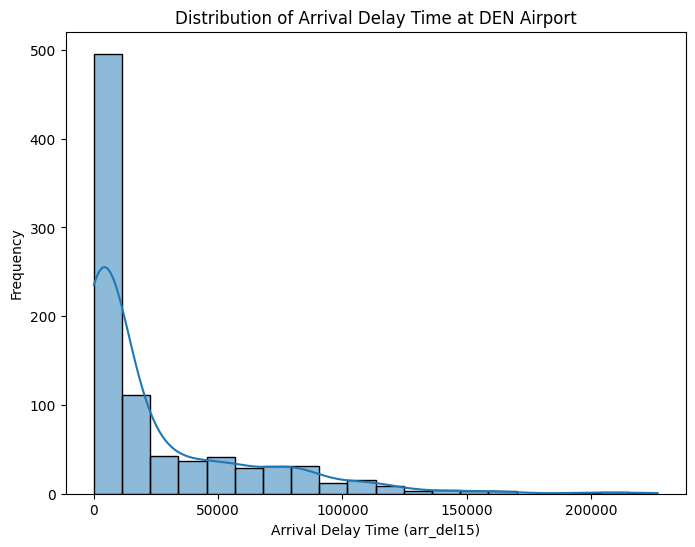

In [34]:
import matplotlib.pyplot as plt
# Assuming 'arr_del15' is the column you want to analyze in den_df
plt.figure(figsize=(8, 6))
sns.histplot(den_df['arr_delay'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Arrival Delay Time (arr_del15)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Time at DEN Airport')
plt.show()


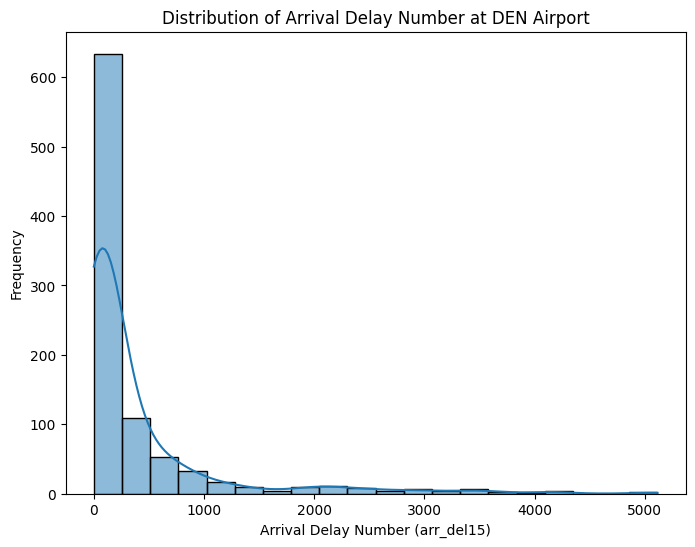

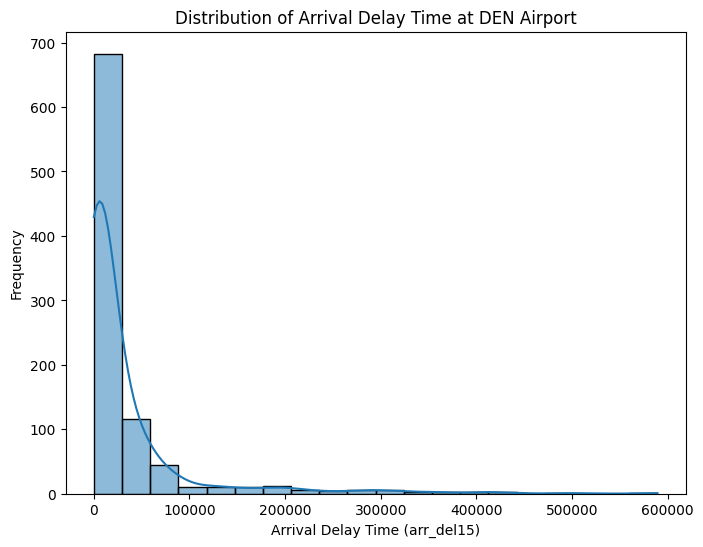

In [35]:
dfw_df = df[df['airport'] == 'DFW']

plt.figure(figsize=(8, 6))
sns.histplot(dfw_df['arr_del15'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Arrival Delay Number (arr_del15)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Number at DEN Airport')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(dfw_df['arr_delay'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Arrival Delay Time (arr_del15)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Time at DEN Airport')
plt.show()

In [36]:
# prompt: A value is trying to be set on a copy of a slice from a DataFrame.
# Try using .loc[row_indexer,col_indexer] = value instead

# Use .loc to assign the new column
dfw_df.loc[:, 'del_freq'] = dfw_df['arr_del15'] / dfw_df['arr_flights'] * 100

max_freq_index = dfw_df['del_freq'].idxmax()
df.loc[max_freq_index]

<ipython-input-36-b474cfc1fb39>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfw_df.loc[:, 'del_freq'] = dfw_df['arr_del15'] / dfw_df['arr_flights'] * 100


,952
year,2024
month,12
carrier,9E
carrier_name,Endeavor Air Inc.
airport,DFW
airport_name,"Dallas/Fort Worth, TX: Dallas/Fort Worth Inter..."
arr_flights,2.0
arr_del15,2.0
carrier_ct,0.0
weather_ct,0.0


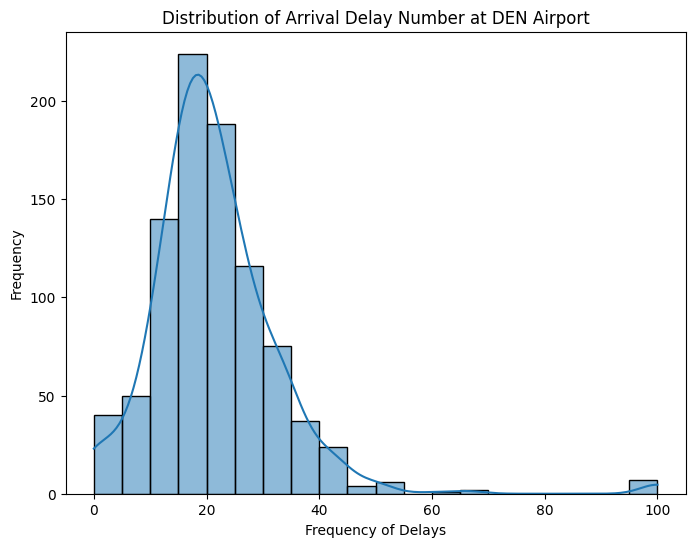

In [37]:
plt.figure(figsize=(8, 6))
sns.histplot(dfw_df['del_freq'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Frequency of Delays')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Number at DEN Airport')
plt.show()

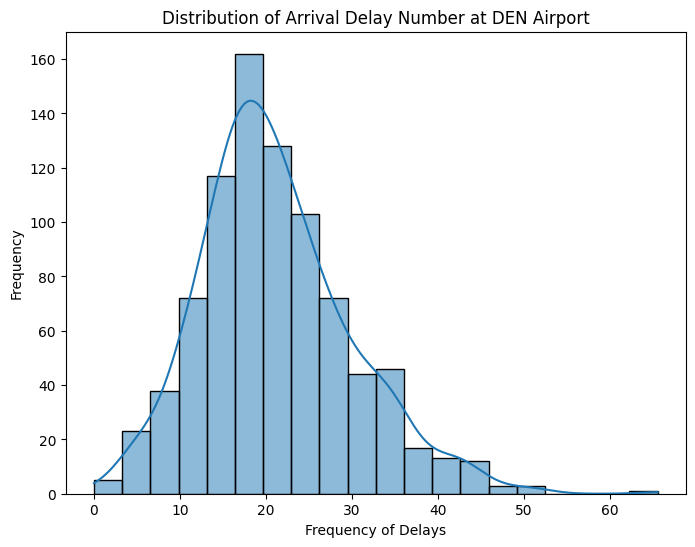

In [38]:
# with a min flight threshold
min_flight_threshold = 10
dfw_df = dfw_df[dfw_df['arr_flights'] > min_flight_threshold]

plt.figure(figsize=(8, 6))
sns.histplot(dfw_df['del_freq'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Frequency of Delays')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Number at DEN Airport')
plt.show()